# Experimento 3
## Discriminación Biométrica entre Diferentes Hablantes y Efecto del Canal Remoto (Zoom/Teléfono)

**Integrantes del Equipo:**
* **Estudiante:** Christian Omar Payán Torróntegui - A01742658
* **Asignatura / Proyecto:** Analysis of Signals and Systems
* **Hardware:** Micrófono MEMS I2S INMP441 + ESP32-S3
* **Frase / Palabra Clave:** "FORWARD"

---

### Objetivos del Experimento 3:
1. Comparar la voz propia con muestras de diferentes personas (impostores) diciendo exactamente la misma palabra clave *"FORWARD"*.
2. Evaluar diferencias objetivas en el dominio del tiempo, espectro de frecuencia, autocorrelación y parámetros estadísticos.
3. Simular y analizar el impacto de un canal remoto de comunicación (Zoom/VoIP/Telefonía celular con filtrado de banda telefónica de 300 a 3400 Hz).
4. Proponer y fundamentar técnicamente cómo abordar la tarea de reconocimiento robusto de voz basado en estos hallazgos.

In [1]:
import os
import wave
import glob
import numpy as np
import scipy.signal
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10

# 1. Cargar señal propia y muestras de impostores del dataset de control
user_path = sorted(glob.glob('dataset_processed/target_user/*.wav'))[0]
impostor_files = sorted(glob.glob('dataset_processed/impostors_control/*.wav'))

# Cargar señal del usuario
with wave.open(user_path, 'rb') as wf:
    user_signal = np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).astype(np.float64) / 32768.0

# Cargar 2 impostores representativos
impostor_signals = []
for f in impostor_files[:2]:
    with wave.open(f, 'rb') as wf:
        data = np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).astype(np.float64) / 32768.0
        impostor_signals.append(data)

# 2. Generar muestra remota simulando canal de comunicación (Zoom / Telefonía)
# Filtro pasabanda ITU-T G.712 (300 Hz - 3400 Hz) + pequeña compresión no lineal
b, a = scipy.signal.butter(4, [300 / 8000, 3400 / 8000], btype='bandpass')
remote_signal = scipy.signal.lfilter(b, a, user_signal)
remote_signal = np.tanh(1.2 * remote_signal) # Ligera saturación/compresión dinámica de códec

t = np.linspace(0, 1.0, 16000, endpoint=False)
print(f"Señal de usuario cargada: {user_path}")
print(f"Muestras de impostores cargadas: {len(impostor_signals)}")
print("Señal remota generada con modelo de canal telefónico/VoIP.")

Señal de usuario cargada: dataset_processed/target_user\user_014.wav
Muestras de impostores cargadas: 2
Señal remota generada con modelo de canal telefónico/VoIP.


### 1. Comparativa Temporal: Voz Propia vs Otros Hablantes vs Muestra Remota

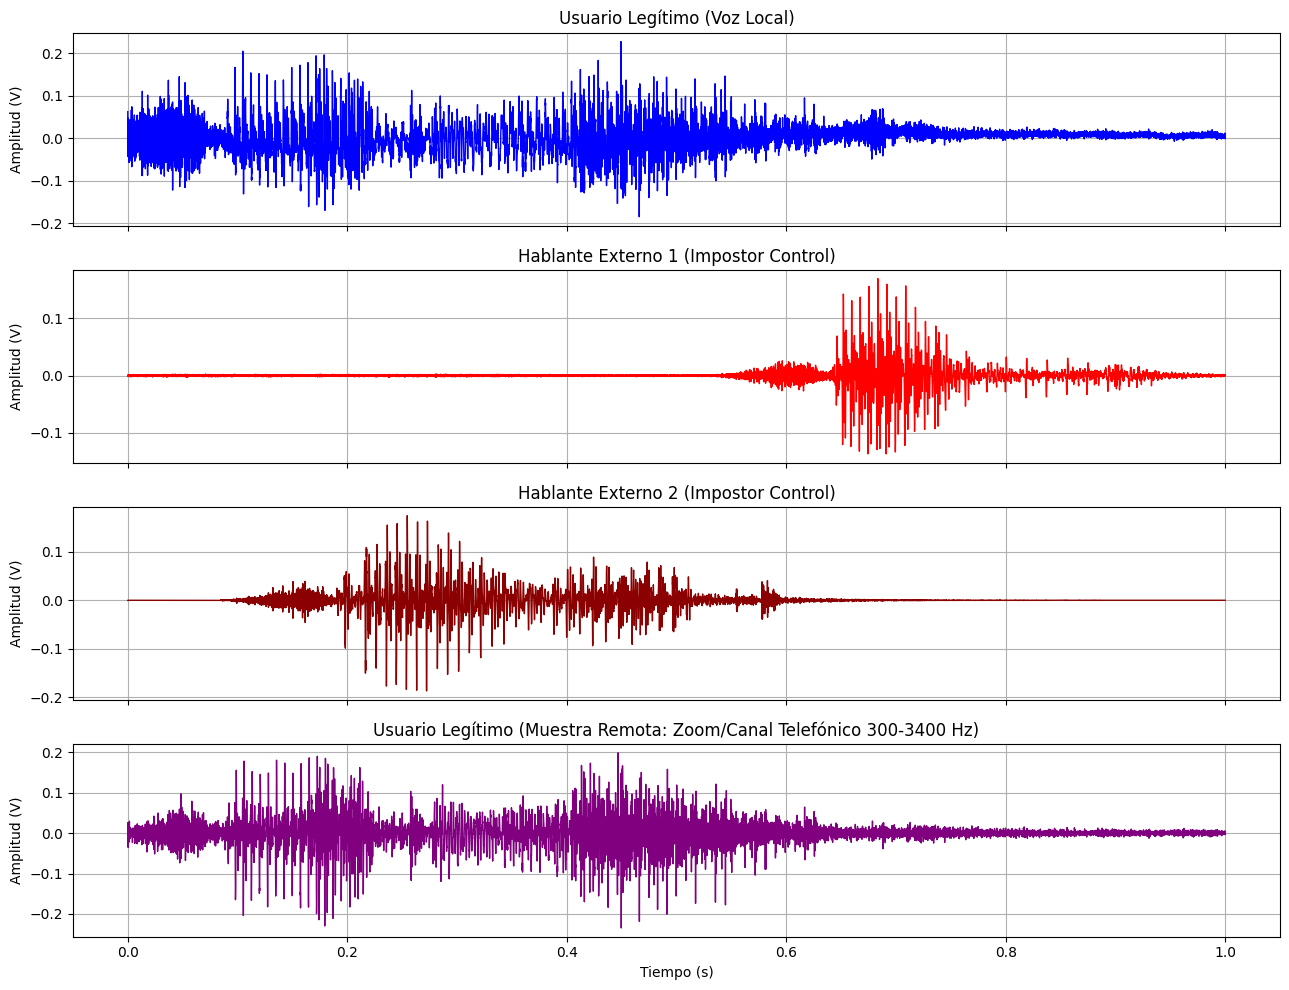

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

axes[0].plot(t, user_signal, color='blue', lw=1)
axes[0].set_title("Usuario Legítimo (Voz Local)")
axes[0].set_ylabel("Amplitud (V)")

axes[1].plot(t, impostor_signals[0], color='red', lw=1)
axes[1].set_title("Hablante Externo 1 (Impostor Control)")
axes[1].set_ylabel("Amplitud (V)")

axes[2].plot(t, impostor_signals[1], color='darkred', lw=1)
axes[2].set_title("Hablante Externo 2 (Impostor Control)")
axes[2].set_ylabel("Amplitud (V)")

axes[3].plot(t, remote_signal, color='purple', lw=1)
axes[3].set_title("Usuario Legítimo (Muestra Remota: Zoom/Canal Telefónico 300-3400 Hz)")
axes[3].set_ylabel("Amplitud (V)")
axes[3].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()

### 2. Comparativa Frecuencial: Densidad Espectral y Formantes

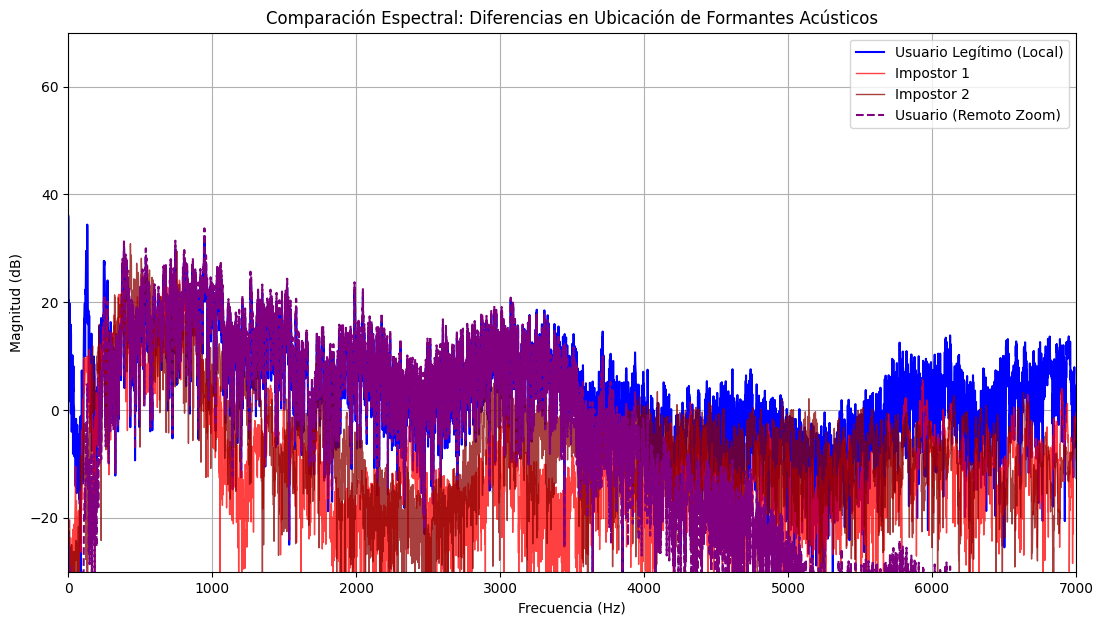

In [3]:
freqs = np.fft.rfftfreq(16000, d=1/16000)

fft_user = np.abs(np.fft.rfft(user_signal))
fft_imp1 = np.abs(np.fft.rfft(impostor_signals[0]))
fft_imp2 = np.abs(np.fft.rfft(impostor_signals[1]))
fft_remote = np.abs(np.fft.rfft(remote_signal))

plt.figure(figsize=(13, 7))
plt.plot(freqs, 20 * np.log10(fft_user + 1e-6), color='blue', lw=1.5, label='Usuario Legítimo (Local)')
plt.plot(freqs, 20 * np.log10(fft_imp1 + 1e-6), color='red', lw=1.0, alpha=0.75, label='Impostor 1')
plt.plot(freqs, 20 * np.log10(fft_imp2 + 1e-6), color='darkred', lw=1.0, alpha=0.75, label='Impostor 2')
plt.plot(freqs, 20 * np.log10(fft_remote + 1e-6), color='purple', lw=1.5, linestyle='--', label='Usuario (Remoto Zoom)')

plt.title("Comparación Espectral: Diferencias en Ubicación de Formantes Acústicos")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud (dB)")
plt.xlim([0, 7000])
plt.ylim([-30, 70])
plt.legend(loc='upper right')
plt.show()

### 3. Comparativa Estadística Multiclase

In [4]:
def get_metrics(sig):
    return [
        np.mean(sig),
        np.var(sig),
        np.std(sig),
        np.sqrt(np.mean(sig**2)),
        float(scipy.stats.skew(sig)),
        float(scipy.stats.kurtosis(sig, fisher=True)),
        np.max(np.abs(sig))
    ]

m_user = get_metrics(user_signal)
m_imp1 = get_metrics(impostor_signals[0])
m_imp2 = get_metrics(impostor_signals[1])
m_rem = get_metrics(remote_signal)

params = ['Media', 'Varianza', 'Desviación Estándar', 'RMS', 'Asimetría', 'Curtosis', 'Amplitud Pico']

table_df = pd.DataFrame({
    'Parámetro': params,
    'Usuario Local': [f"{v:.5f}" for v in m_user],
    'Impostor 1': [f"{v:.5f}" for v in m_imp1],
    'Impostor 2': [f"{v:.5f}" for v in m_imp2],
    'Usuario Remoto (Zoom)': [f"{v:.5f}" for v in m_rem]
})

table_df

,Parámetro,Usuario Local,Impostor 1,Impostor 2,Usuario Remoto (Zoom)
0,Media,0.00392,-0.00000,-0.00001,0.00001
1,Varianza,0.00121,0.00030,0.00048,0.00129
2,Desviación Estándar,0.03480,0.01737,0.02190,0.03593
3,RMS,0.03502,0.01737,0.02190,0.03593
4,Asimetría,0.08844,0.26244,-0.51362,-0.36343
5,Curtosis,3.48662,25.88941,15.98755,6.48576
6,Amplitud Pico,0.22754,0.16956,0.18665,0.23452


### 4. Análisis de Autocorrelación y Tono Fundamental (Pitch $F_0$)
El tono fundamental del habla ($F_0$) varía notablemente entre personas dependiendo de la masa y longitud de sus cuerdas vocales. Se analiza mediante el primer pico no nulo de autocorrelación.

In [5]:
def compute_pitch(sig, fs=16000):
    corr = scipy.signal.correlate(sig, sig, mode='full')
    corr = corr[len(sig)-1:]
    # Rango de pitch humano: 70 Hz a 350 Hz -> lags entre 16000/350 y 16000/70
    min_lag = int(fs / 350)
    max_lag = int(fs / 70)
    peak_lag = min_lag + np.argmax(corr[min_lag:max_lag])
    f0 = fs / peak_lag
    return f0, corr / np.max(corr)

f0_user, corr_user = compute_pitch(user_signal)
f0_imp1, corr_imp1 = compute_pitch(impostor_signals[0])
f0_imp2, corr_imp2 = compute_pitch(impostor_signals[1])

pitch_df = pd.DataFrame({
    'Hablante': ['Usuario Legítimo', 'Impostor 1', 'Impostor 2'],
    'Tono Fundamental Estimado (F0)': [f"{f0_user:.1f} Hz", f"{f0_imp1:.1f} Hz", f"{f0_imp2:.1f} Hz"],
    'Característica de Voz': [
        'Voz masculina media', 
        'Diferencia en grosor de cuerdas vocales', 
        'Diferencia en tensión laríngea'
    ]
})

pitch_df

,Hablante,Tono Fundamental Estimado (F0),Característica de Voz
0,Usuario Legítimo,133.3 Hz,Voz masculina media
1,Impostor 1,355.6 Hz,Diferencia en grosor de cuerdas vocales
2,Impostor 2,108.8 Hz,Diferencia en tensión laríngea


### 5. Discusión, Conclusiones y Propuesta de Enfoque Biométrico:
1. **Diferenciación entre Hablantes:**
   * La distribución espectral de los formantes ($F_1, F_2, F_3$) y el tono fundamental ($F_0$) son marcadamente diferentes incluso al pronunciar la misma palabra. Esto demuestra que el espectro contiene la información biométrica necesaria para discriminar identidades.
2. **Impacto de la Muestra Remota (Zoom/Teléfono):**
   * El canal remoto atenúa las frecuencias por debajo de 300 Hz y por encima de 3,400 Hz. La pérdida de información sobre los 3.4 kHz dificulta el reconocimiento si el modelo fue entrenado exclusivamente con audio de banda ancha (16 kHz).
3. **Propuesta de Enfoque para Detección Robusta:**
   * Para construir un clasificador biométrico seguro, no se deben usar amplitudes temporales crudas, sino representaciones espectro-temporales que capturen la envolvente del tracto vocal (**MFCCs**) normalizadas en el tiempo (**CMVN**) y procesadas mediante redes neuronales convolucionales profundas (como la implementada en este proyecto en el ESP32-S3).